# <center><strong>Maven Toys Analysis</strong></center>
-----------------------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

--------------------------------
--------------------------------
## **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import calendar
from scipy import stats

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [98]:
def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.xlabel('Year')
    plt.show()

def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.title(col)
    plt.show()

def boxplot(data, col):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(8, 4)
    sns.boxplot(data=data,x=col,orient="o",ax=axes)
    plt.show()

def boxplot2(data, x,y):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(10, 5)
    sns.boxplot(data=data,y=y,x=x,orient="v",ax=axes)
    plt.show()

def kde (data,col):
    plt.figure(figsize=(8,	4))
    sns.kdeplot(data[col], fill=True,	color='violet', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def group_distribution(data,col,target):

    groups = data[col].unique()
    
    plt.figure(figsize=(12, 6))
    
    for i, group in enumerate(groups):
        data_group = data[data[col] == group][target]
        
        plt.subplot(3, 2, i+1)
        sns.histplot(data_group, kde=True, color='green')
        plt.title(f'Distribution for {group}')
    
    plt.tight_layout()
    plt.show()

---------------------------------------
---------------------------------------
## **ETL**
-------------------------
- ### **Extract**
-------------------------

In [3]:
stores = pd.read_csv('/kaggle/input/datasets/mohamedjamyl/maven-toys-dataset/Maven Toys Data/stores.csv')
sales = pd.read_csv('/kaggle/input/datasets/mohamedjamyl/maven-toys-dataset/Maven Toys Data/sales.csv')
products = pd.read_csv('/kaggle/input/datasets/mohamedjamyl/maven-toys-dataset/Maven Toys Data/products.csv')
inventory = pd.read_csv('/kaggle/input/datasets/mohamedjamyl/maven-toys-dataset/Maven Toys Data/inventory.csv')
calendar = pd.read_csv('/kaggle/input/datasets/mohamedjamyl/maven-toys-dataset/Maven Toys Data/calendar.csv')

In [4]:
stores.head()

,Store_ID,Store_Name,Store_City,Store_Location,Store_Open_Date
0,1,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18
1,2,Maven Toys Monterrey 1,Monterrey,Residential,1995-04-27
2,3,Maven Toys Guadalajara 2,Guadalajara,Commercial,1999-12-27
3,4,Maven Toys Saltillo 1,Saltillo,Downtown,2000-01-01
4,5,Maven Toys La Paz 1,La Paz,Downtown,2001-05-31


In [5]:
sales.head()


,Sale_ID,Date,Store_ID,Product_ID,Units
0,1,2022-01-01,24,4,1
1,2,2022-01-01,28,1,1
2,3,2022-01-01,6,8,1
3,4,2022-01-01,48,7,1
4,5,2022-01-01,44,18,1


In [6]:
products.head()

,Product_ID,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,Action Figure,Toys,$9.99,$15.99
1,2,Animal Figures,Toys,$9.99,$12.99
2,3,Barrel O' Slime,Art & Crafts,$1.99,$3.99
3,4,Chutes & Ladders,Games,$9.99,$12.99
4,5,Classic Dominoes,Games,$7.99,$9.99


In [7]:
inventory.head()

,Store_ID,Product_ID,Stock_On_Hand
0,1,1,27
1,1,2,0
2,1,3,32
3,1,4,6
4,1,5,0


In [8]:
calendar.head()

,Date
0,1/1/2022
1,1/2/2022
2,1/3/2022
3,1/4/2022
4,1/5/2022


--------------------------------

In [9]:
print(stores.columns)
print('-----------------------------------------------------------------------')
print(sales.columns)
print('-----------------------------------------------------------------------')
print(products.columns)
print('-----------------------------------------------------------------------')
print(inventory.columns)
print('-----------------------------------------------------------------------')
print(calendar.columns)

Index(['Store_ID', 'Store_Name', 'Store_City', 'Store_Location',
       'Store_Open_Date'],
      dtype='object')
-----------------------------------------------------------------------
Index(['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units'], dtype='object')
-----------------------------------------------------------------------
Index(['Product_ID', 'Product_Name', 'Product_Category', 'Product_Cost',
       'Product_Price'],
      dtype='object')
-----------------------------------------------------------------------
Index(['Store_ID', 'Product_ID', 'Stock_On_Hand'], dtype='object')
-----------------------------------------------------------------------
Index(['Date'], dtype='object')


---------------------
- ### **Transform**
---------------------

In [10]:
df = sales.merge(stores, on='Store_ID', how='left')
df.head()

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13
3,4,2022-01-01,48,7,1,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23
4,5,2022-01-01,44,18,1,Maven Toys Puebla 3,Puebla,Residential,2014-12-27


In [11]:
df = df.merge(products,on='Product_ID',how='left')
df.head()

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$9.99,$12.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$9.99,$15.99
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,$3.99,$6.99
3,4,2022-01-01,48,7,1,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,$11.99,$15.99
4,5,2022-01-01,44,18,1,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,$34.99,$39.99


In [12]:
calendar['Date'] = calendar['Date'].apply(lambda x : datetime.strptime(x, '%m/%d/%Y').strftime('%Y-%m-%d'))

In [13]:
df = df.merge(calendar, on='Date', how='left')
df.head()

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$9.99,$12.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$9.99,$15.99
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,$3.99,$6.99
3,4,2022-01-01,48,7,1,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,$11.99,$15.99
4,5,2022-01-01,44,18,1,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,$34.99,$39.99


In [14]:
df = df.merge(inventory, on=['Store_ID', 'Product_ID'], how='left')
df.head()

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_Name,Product_Category,Product_Cost,Product_Price,Stock_On_Hand
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$9.99,$12.99,1.0
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$9.99,$15.99,6.0
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,$3.99,$6.99,50.0
3,4,2022-01-01,48,7,1,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,$11.99,$15.99,28.0
4,5,2022-01-01,44,18,1,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,$34.99,$39.99,117.0


-----------------------------
-----------------------------
## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [15]:
df.head()

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_Name,Product_Category,Product_Cost,Product_Price,Stock_On_Hand
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$9.99,$12.99,1.0
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$9.99,$15.99,6.0
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,$3.99,$6.99,50.0
3,4,2022-01-01,48,7,1,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,$11.99,$15.99,28.0
4,5,2022-01-01,44,18,1,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,$34.99,$39.99,117.0


In [16]:
df.shape

(829262, 14)

In [17]:
df.columns

Index(['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units', 'Store_Name',
       'Store_City', 'Store_Location', 'Store_Open_Date', 'Product_Name',
       'Product_Category', 'Product_Cost', 'Product_Price', 'Stock_On_Hand'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Sale_ID           829262 non-null  int64  
 1   Date              829262 non-null  object 
 2   Store_ID          829262 non-null  int64  
 3   Product_ID        829262 non-null  int64  
 4   Units             829262 non-null  int64  
 5   Store_Name        829262 non-null  object 
 6   Store_City        829262 non-null  object 
 7   Store_Location    829262 non-null  object 
 8   Store_Open_Date   829262 non-null  object 
 9   Product_Name      829262 non-null  object 
 10  Product_Category  829262 non-null  object 
 11  Product_Cost      829262 non-null  object 
 12  Product_Price     829262 non-null  object 
 13  Stock_On_Hand     823030 non-null  float64
dtypes: float64(1), int64(4), object(9)
memory usage: 88.6+ MB


In [19]:
df.isnull().sum()

Sale_ID                0
Date                   0
Store_ID               0
Product_ID             0
Units                  0
Store_Name             0
Store_City             0
Store_Location         0
Store_Open_Date        0
Product_Name           0
Product_Category       0
Product_Cost           0
Product_Price          0
Stock_On_Hand       6232
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

------------------------------
### **Data Cleaning** 
------------------------------

In [21]:
df['Product_Cost'].value_counts()

Product_Cost
$1.99      118912
$3.99      115006
$9.99      112628
$6.99       97366
$13.99      63943
$34.99      48030
$7.99       45828
$10.99      41550
$14.99      39252
$17.99      38703
$11.99      32291
$5.99       24507
$20.99      16561
$8.99       14722
$2.99       12143
$4.99        7820
Name: count, dtype: int64

In [22]:
df = df.dropna()

In [23]:
df.columns

Index(['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units', 'Store_Name',
       'Store_City', 'Store_Location', 'Store_Open_Date', 'Product_Name',
       'Product_Category', 'Product_Cost', 'Product_Price', 'Stock_On_Hand'],
      dtype='object')

In [24]:
df['Product_Cost'].value_counts()

Product_Cost
$1.99      118912
$3.99      114950
$9.99      112575
$6.99       97366
$13.99      63879
$34.99      48030
$7.99       45705
$10.99      41550
$14.99      39252
$17.99      38703
$11.99      32291
$5.99       24507
$20.99      16561
$8.99       14575
$4.99        7804
$2.99        6370
Name: count, dtype: int64

In [25]:
df['Product_Cost'] = df['Product_Cost'].str.replace('$', '', regex=False)
df['Product_Cost'] = df['Product_Cost'].astype(float)

In [26]:
df['Product_Price'].value_counts()

Product_Price
$15.99     113993
$14.99     103387
$19.99      92276
$6.99       68083
$2.99       64834
$10.99      55500
$3.99       54078
$39.99      48030
$9.99       42698
$12.99      41931
$8.99       41559
$20.99      26748
$5.99       20776
$4.99       20736
$25.99      10494
$24.99       8552
$11.99       6812
$7.99        2543
Name: count, dtype: int64

In [27]:
df['Product_Price'] = df['Product_Price'].str.replace('$','', regex=False)
df['Product_Price'] = df['Product_Price'].astype(float)

In [28]:
df['Product_Price'].value_counts()

Product_Price
15.99    113993
14.99    103387
19.99     92276
6.99      68083
2.99      64834
10.99     55500
3.99      54078
39.99     48030
9.99      42698
12.99     41931
8.99      41559
20.99     26748
5.99      20776
4.99      20736
25.99     10494
24.99      8552
11.99      6812
7.99       2543
Name: count, dtype: int64

-----------------------------------------
### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**

In [29]:
df.describe()

,Sale_ID,Store_ID,Product_ID,Units,Product_Cost,Product_Price,Stock_On_Hand
count,823030.000000,823030.000000,823030.000000,823030.000000,823030.000000,823030.000000,823030.000000
mean,414855.482199,25.267391,15.005944,1.316952,10.026130,13.797757,25.319432
std,239754.243075,14.358599,9.902840,0.833016,7.824972,8.690296,22.955019
min,1.000000,1.000000,1.000000,1.000000,1.990000,2.990000,0.000000
25%,206841.250000,13.000000,6.000000,1.000000,3.990000,6.990000,9.000000
50%,415225.500000,26.000000,14.000000,1.000000,7.990000,12.990000,18.000000
75%,622638.750000,38.000000,24.000000,1.000000,13.990000,15.990000,35.000000
max,829262.000000,50.000000,35.000000,30.000000,34.990000,39.990000,139.000000


In [30]:
df.select_dtypes(include='object').describe()

,Date,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_Name,Product_Category
count,823030,823030,823030,823030,823030,823030,823030
unique,638,50,29,4,50,35,5
top,2023-04-30,Maven Toys Ciudad de Mexico 2,Cuidad de Mexico,Downtown,2012-05-04,Colorbuds,Toys
freq,3071,28497,89969,476521,28497,72988,221161


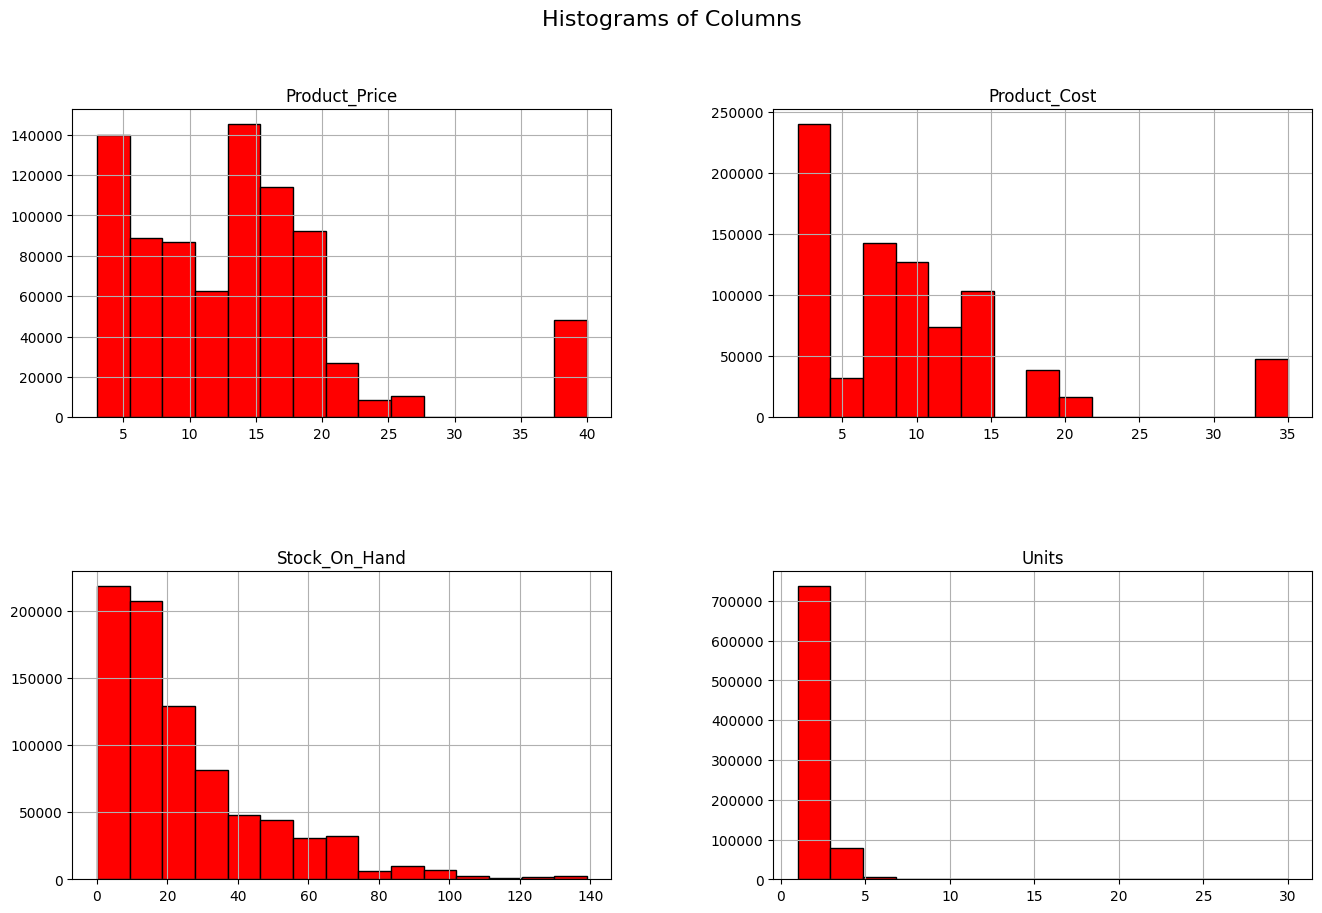

In [31]:
df[['Product_Price','Product_Cost','Stock_On_Hand','Units']].hist(bins=15, figsize=(16, 10), color='red', edgecolor='black')
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  
plt.show()

--------------------------------
- Summary Statistical : **value_counts()**

In [32]:
df.columns

Index(['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units', 'Store_Name',
       'Store_City', 'Store_Location', 'Store_Open_Date', 'Product_Name',
       'Product_Category', 'Product_Cost', 'Product_Price', 'Stock_On_Hand'],
      dtype='object')

In [33]:
df['Store_Location'].value_counts()

Store_Location
Downtown       476521
Commercial     183243
Residential     95621
Airport         67645
Name: count, dtype: int64

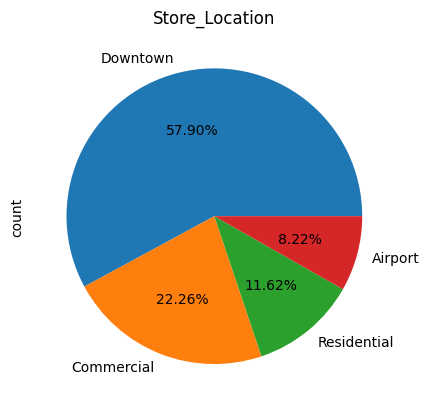

In [34]:
pie(df,'Store_Location')

In [35]:
df['Product_Category'].value_counts()

Product_Category
Toys                 221161
Art & Crafts         220673
Games                150937
Sports & Outdoors    131234
Electronics           99025
Name: count, dtype: int64

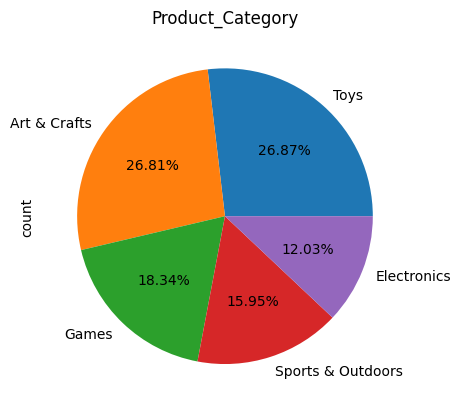

In [36]:
pie(df, 'Product_Category')

In [37]:
df['Store_City'].value_counts()

Store_City
Cuidad de Mexico    89969
Guadalajara         73519
Monterrey           68873
Hermosillo          49773
Guanajuato          49202
Puebla              47079
Toluca              35366
Mexicali            33596
Xalapa              33187
Saltillo            33090
Chihuahua           30578
Campeche            30500
Villahermosa        16324
Santiago            15873
Ciudad Victoria     15866
San Luis Potosi     15499
Pachuca             14969
Morelia             14956
Merida              14875
Chetumal            14644
Culiacan            14594
Aguascalientes      14588
Tuxtla Gutierrez    14441
Chilpancingo        14438
Durango             13967
Oaxaca              13741
Cuernavaca          13335
Zacatecas           13264
La Paz              12924
Name: count, dtype: int64

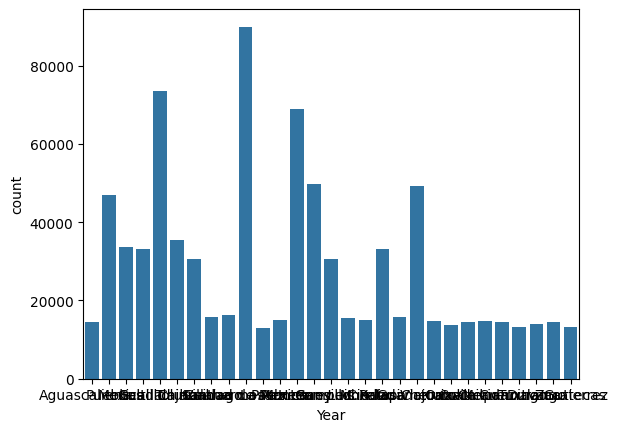

In [38]:
countplot(df,'Store_City')

---------------------------------
---------------------------------
## **Detect Outliers**
---------------------------------

In [39]:
df['Product_Price'].describe()

count    823030.000000
mean         13.797757
std           8.690296
min           2.990000
25%           6.990000
50%          12.990000
75%          15.990000
max          39.990000
Name: Product_Price, dtype: float64

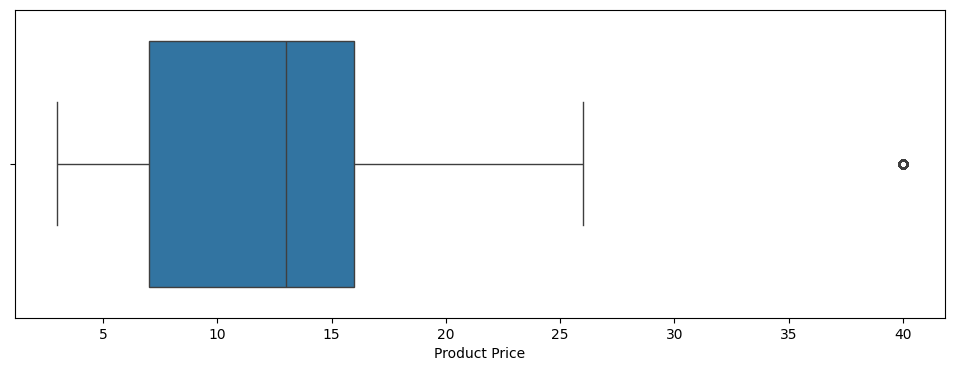

In [40]:
fig, axes = plt.subplots(nrows=1,ncols=1)
fig.set_size_inches(12, 4)
sns.boxplot(data=df,x="Product_Price",orient="o",ax=axes)
plt.xlabel('Product Price')
plt.show()

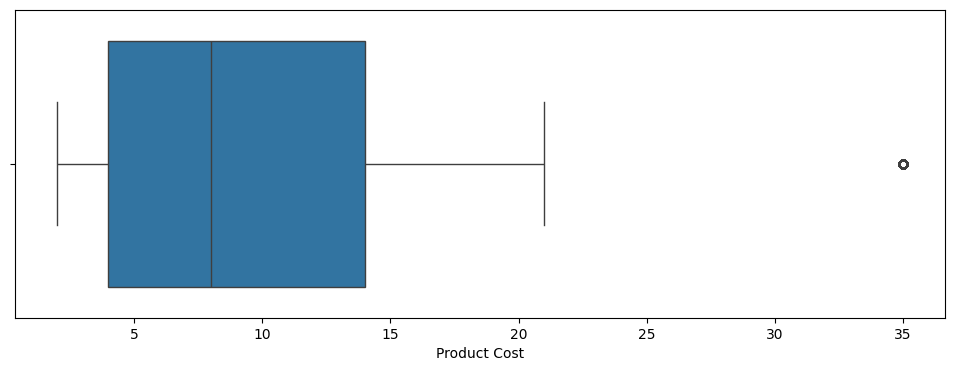

In [41]:
fig, axes = plt.subplots(nrows=1,ncols=1)
fig.set_size_inches(12, 4)
sns.boxplot(data=df,x="Product_Cost",orient="o",ax=axes)
plt.xlabel('Product Cost')
plt.show()

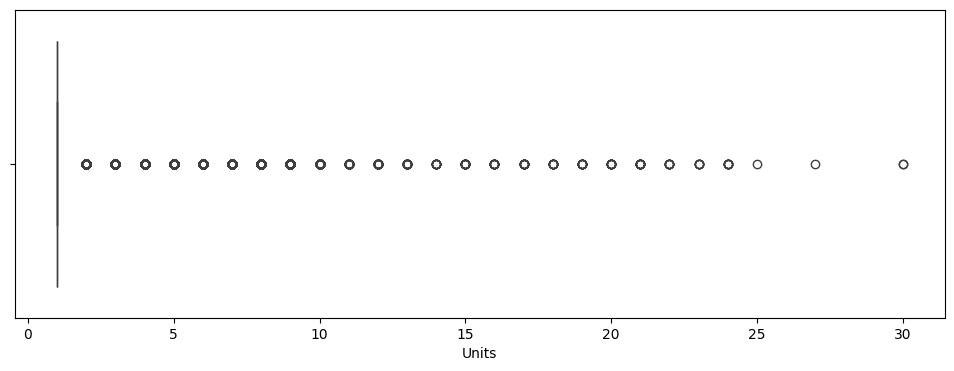

In [42]:
fig, axes = plt.subplots(nrows=1,ncols=1)
fig.set_size_inches(12, 4)
sns.boxplot(data=df,x="Units",orient="o",ax=axes)
plt.xlabel('Units')
plt.show()

------------------------------------------
------------------------------------------
## **Feature Extraction**
------------------------------------------

In [43]:
df['Store_Open_year'] = df['Store_Open_Date'].apply(lambda x : x.split('-')[0])

In [44]:
df['Store_Open_year'] = df['Store_Open_year'].astype(int)

In [45]:
dtime=datetime.now()
df['Store age']=dtime.year-df['Store_Open_year']

In [46]:
df['Store age']

0         16
1         15
2         23
3         10
4         12
          ..
829257    16
829258    19
829259    16
829260    20
829261    14
Name: Store age, Length: 823030, dtype: int64

In [47]:
def segYear(a):
    if a < 15 :
        return 'Established'
    elif a < 20:
        return 'Experienced'
    elif a < 25 :
        return 'Mature'
    elif a < 30 :
        return 'Senior'
    else :
        return 'Legacy'

df['Store age seg'] = df['Store age'].apply(lambda x : segYear(x))

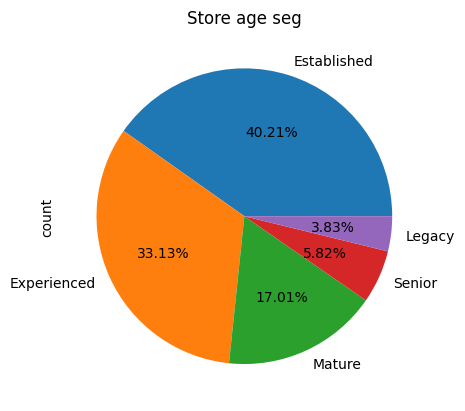

In [48]:
pie(df,'Store age seg')

------------------------------------

In [49]:
df['Year']=df['Date'].apply(lambda x: x.split('-')[0])
df['Year'] = df['Year'].astype(int)

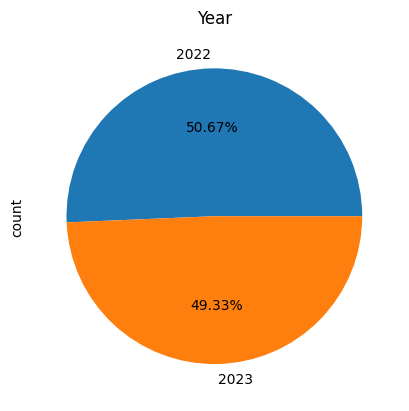

In [50]:
pie(df,'Year')

---------------------------

In [51]:
df['Month'] = pd.to_datetime(df['Date']).dt.month_name()
df["Month"]

0           January
1           January
2           January
3           January
4           January
            ...    
829257    September
829258    September
829259    September
829260    September
829261    September
Name: Month, Length: 823030, dtype: object

In [52]:
season_map = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn'
}

df['Season'] = df['Month'].map(season_map)
df['Season']

0         Winter
1         Winter
2         Winter
3         Winter
4         Winter
           ...  
829257    Autumn
829258    Autumn
829259    Autumn
829260    Autumn
829261    Autumn
Name: Season, Length: 823030, dtype: object

In [53]:
df['Day'] = pd.to_datetime(df['Date']).dt.day_name()
df["Day"]

0         Saturday
1         Saturday
2         Saturday
3         Saturday
4         Saturday
            ...   
829257    Saturday
829258    Saturday
829259    Saturday
829260    Saturday
829261    Saturday
Name: Day, Length: 823030, dtype: object

In [54]:
def WeekEnd(day):
    day = str(day)
    if day == 'Saturday' or day == 'Sunday':
        return 'weekend'
    else:
        return 'no'

df['Weekend'] = df['Day'].apply(lambda x : WeekEnd(x))
df['Weekend']

0         weekend
1         weekend
2         weekend
3         weekend
4         weekend
           ...   
829257    weekend
829258    weekend
829259    weekend
829260    weekend
829261    weekend
Name: Weekend, Length: 823030, dtype: object

In [55]:
df.columns

Index(['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units', 'Store_Name',
       'Store_City', 'Store_Location', 'Store_Open_Date', 'Product_Name',
       'Product_Category', 'Product_Cost', 'Product_Price', 'Stock_On_Hand',
       'Store_Open_year', 'Store age', 'Store age seg', 'Year', 'Month',
       'Season', 'Day', 'Weekend'],
      dtype='object')

In [56]:
df['Revenue'] = df['Product_Price']*df['Units']
df['Revenue']

0         12.99
1         15.99
2          6.99
3         15.99
4         39.99
          ...  
829257    15.99
829258     7.99
829259    15.99
829260    25.98
829261    14.99
Name: Revenue, Length: 823030, dtype: float64

In [57]:
df['Gross Profit'] = df['Revenue'] - (df['Product_Cost']*df['Units'])
df['Gross Profit']

0         3.0
1         6.0
2         3.0
3         4.0
4         5.0
         ... 
829257    2.0
829258    4.0
829259    2.0
829260    6.0
829261    8.0
Name: Gross Profit, Length: 823030, dtype: float64

In [58]:
df['Gross Profit Margin'] = df['Gross Profit'] / df['Revenue']
df['Gross Profit Margin']

0         0.230947
1         0.375235
2         0.429185
3         0.250156
4         0.125031
            ...   
829257    0.125078
829258    0.500626
829259    0.125078
829260    0.230947
829261    0.533689
Name: Gross Profit Margin, Length: 823030, dtype: float64

In [59]:
df[['Product_Cost', 'Product_Price','Revenue','Units','Gross Profit','Stock_On_Hand']]

,Product_Cost,Product_Price,Revenue,Units,Gross Profit,Stock_On_Hand
0,9.99,12.99,12.99,1,3.0,1.0
1,9.99,15.99,15.99,1,6.0,6.0
2,3.99,6.99,6.99,1,3.0,50.0
3,11.99,15.99,15.99,1,4.0,28.0
4,34.99,39.99,39.99,1,5.0,117.0
...,...,...,...,...,...,...
829257,13.99,15.99,15.99,1,2.0,67.0
829258,3.99,7.99,7.99,1,4.0,6.0
829259,13.99,15.99,15.99,1,2.0,17.0
829260,9.99,12.99,25.98,2,6.0,2.0


In [60]:
df.drop(['Sale_ID', 'Date', 'Store_ID', 'Product_ID','Store age','Store_Open_Date','Store_Open_year'],axis=1,inplace=True)

In [61]:
#df.to_excel('Maven Toys cleaned dataset.xlsx',index=False)

In [62]:
df = df.loc[(df['Month'] != 'October') & (df['Month'] != 'November') & (df['Month'] != 'December')]

In [63]:
df.to_excel('Maven Toys cleaned dataset.xlsx',index=False)

-----------------------------
### **Checking Correlation between the features**
-----------------------------

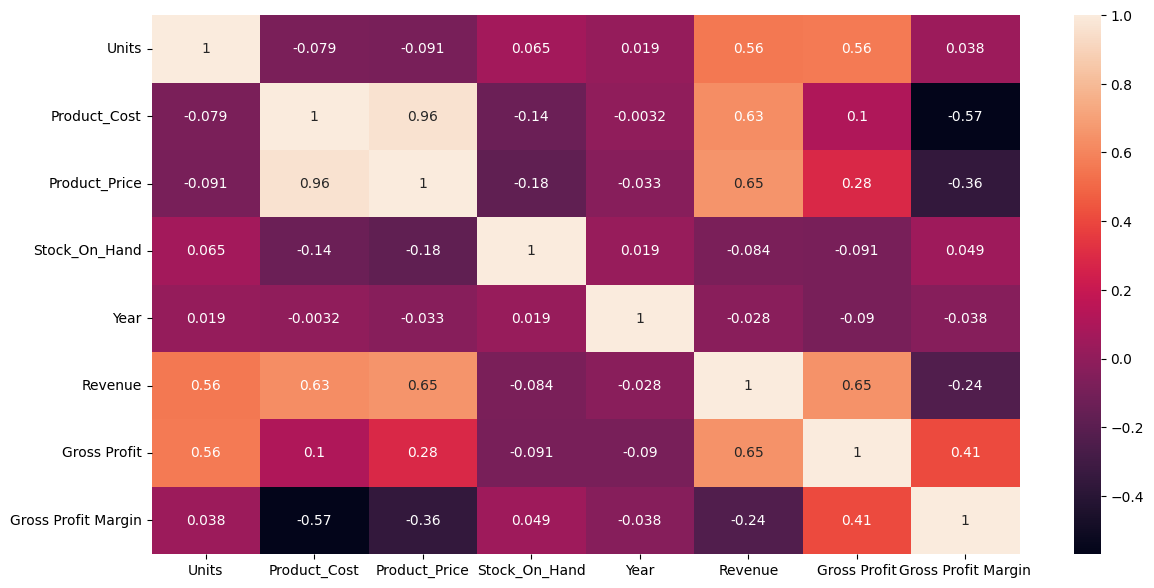

In [64]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

In [65]:
def regplot(df, x, y):
     plt.figure(figsize=(16, 5))
     sns.regplot(x=x, y=y, data=df)
     plt.show()

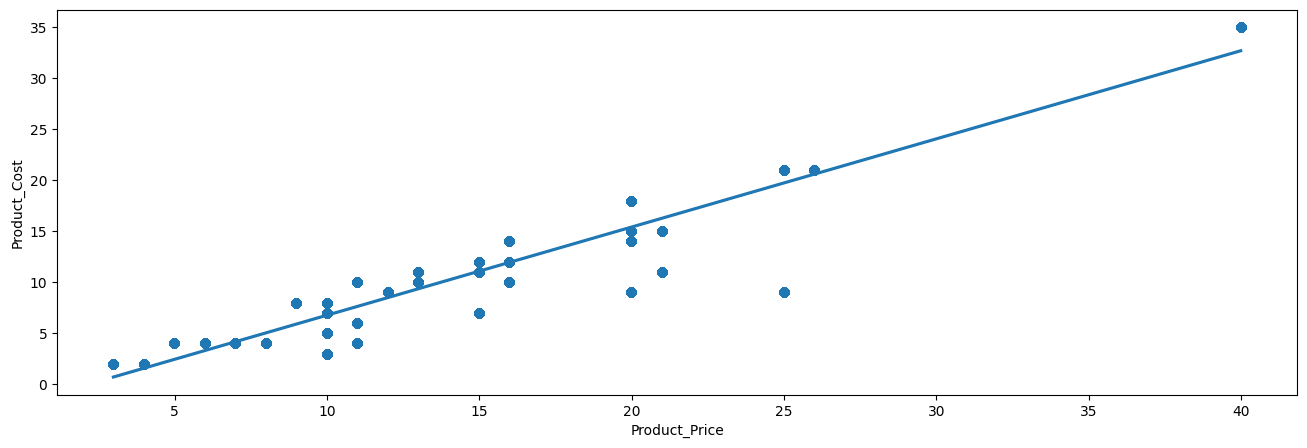

In [66]:
regplot(df, 'Product_Price', 'Product_Cost')

- ##### **Positive Correlation:** There is a clear upward trend. As the price of a product increases, the cost to produce or acquire it generally increases as well.

- ##### **Linear Relationship:** The data points follow a relatively straight path, suggesting that a linear model is a good starting point for predicting cost based on price.

- ##### **Variance (Spread):** While the trend is strong, notice that as the price increases (especially past 20), the "vertical spread" of the dots increases. This indicates that for higher-priced items, the cost is less predictable than for cheaper items.

- ##### **Outliers:** There are a few interesting points, such as the one at a price of 25 with a cost of only about 9. This represents a product with a much higher profit margin compared to the others.

----------------------------
----------------------------
## ***Analysis Store City by Gross profit across year and season and month and day***
------------------------------
### **1- Gross profit by store city Across Year**
-----------------------

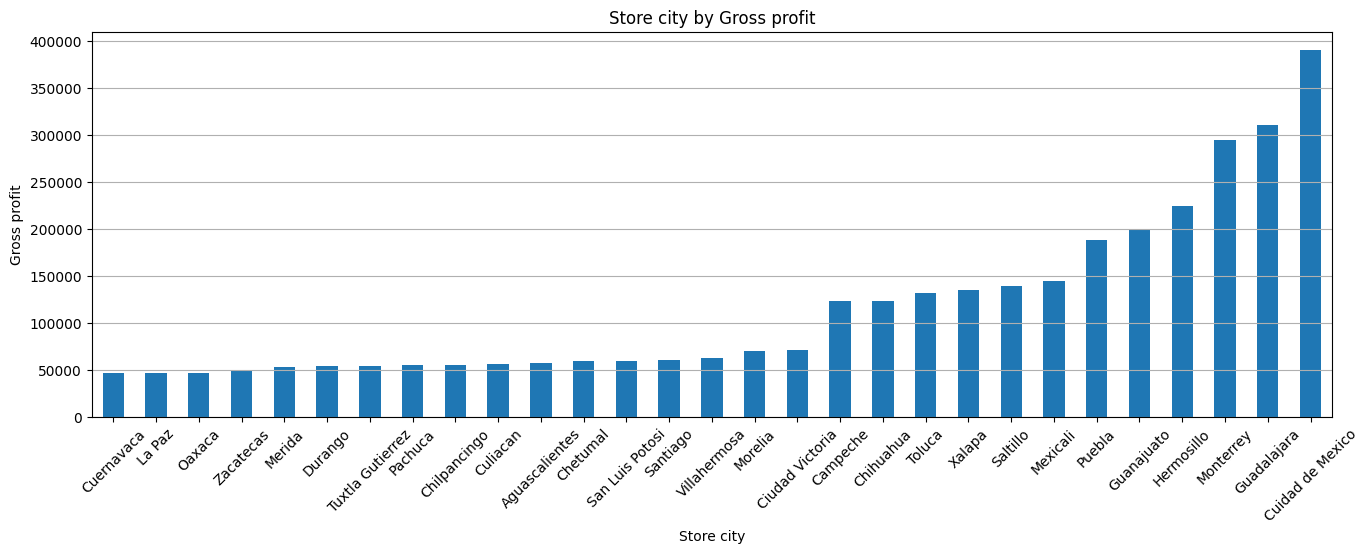

In [67]:
storeCity_profit = df.groupby('Store_City')['Gross Profit'].sum().sort_values()

plt.figure(figsize=(16,5))
storeCity_profit.plot(kind='bar')
plt.title('Store city by Gross profit')
plt.xlabel('Store city')
plt.ylabel('Gross profit')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

- ##### **Significant Disparity:** There is a massive gap between the highest and lowest performers. The gross profit in Ciudad de México is roughly 8 times higher than in Cuernavaca.

- ##### **The "Mid-Tier" Plateau:** A large group of cities (from Cuernavaca through Morelia) shows relatively flat, incremental growth. The profit levels in these 20 cities remain under 100,000.

- ##### **The Growth Surge:** Starting from Mexicali and Puebla, there is a much steeper "climb" in the bars, indicating that these markets are significantly more lucrative than the baseline stores.

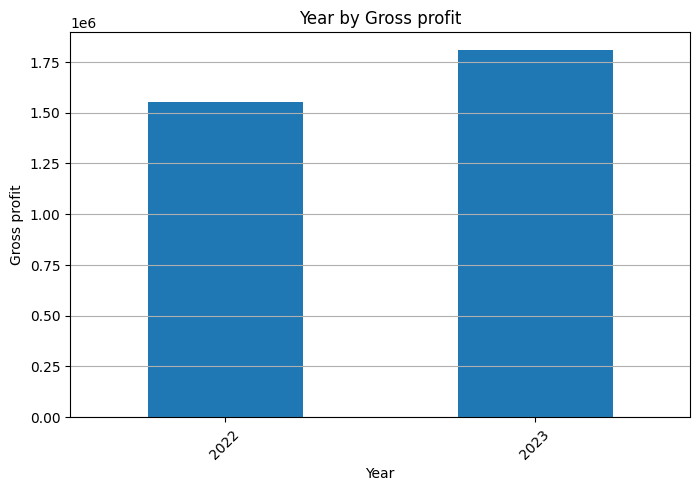

In [68]:
Year_profit = df.groupby('Year')['Gross Profit'].sum().sort_values()

plt.figure(figsize=(8,5))
Year_profit.plot(kind='bar')
plt.title('Year by Gross profit')
plt.xlabel('Year')
plt.ylabel('Gross profit')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

- ##### **2022 Total Gross Profit:** Approximately $1.77 million.

- ##### **2023 Total Gross Profit:** Approximately $1.52 million.

- ##### **Net Trend:** This represents a increase of roughly 16% in total gross profit year-over-year

<Figure size 1400x500 with 0 Axes>

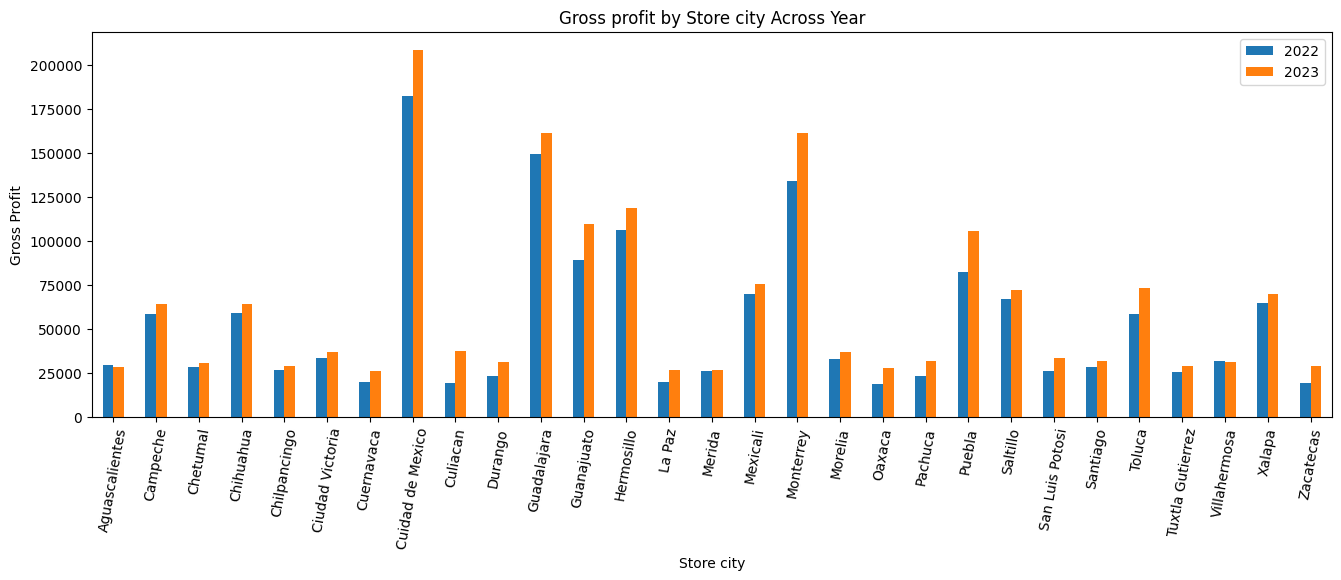

In [69]:
year_dept = df.groupby(['Year', 'Store_City'])['Gross Profit'].sum().reset_index()

pivot_sd = year_dept.pivot(index='Store_City', columns='Year', values='Gross Profit')

plt.figure(figsize=(14,5))
pivot_sd.plot(kind='bar', figsize=(16,5))
plt.title('Gross profit by Store city Across Year')
plt.ylabel('Gross Profit')
plt.xlabel('Store city')
plt.xticks(rotation=80)
plt.legend()
plt.show()

- ##### **Ciudad de Mexico:** By far the highest performer, crossing the $200,000 mark in 2023.

- ##### **Guadalajara:** The second strongest market, with 2023 profits exceeding $150,000.

- ##### **Monterrey:** Showed significant strength, moving from roughly 135,000 to over 160,000.

- ##### **Hermosillo & Puebla:** Both are strong mid-tier performers, consistently generating high profits.

-----------------------
### **2- Gross profit by store city Across Season**
-----------------------

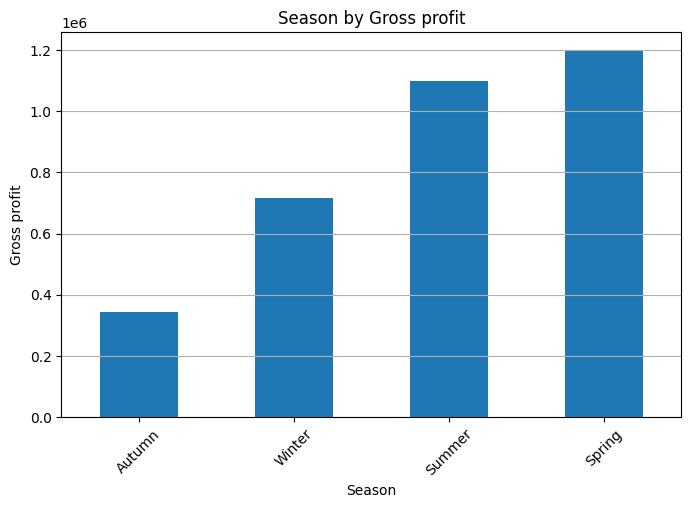

In [70]:
Season_profit = df.groupby('Season')['Gross Profit'].sum().sort_values()

plt.figure(figsize=(8,5))
Season_profit.plot(kind='bar')
plt.title('Season by Gross profit')
plt.xlabel('Season')
plt.ylabel('Gross profit')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

<Figure size 1400x500 with 0 Axes>

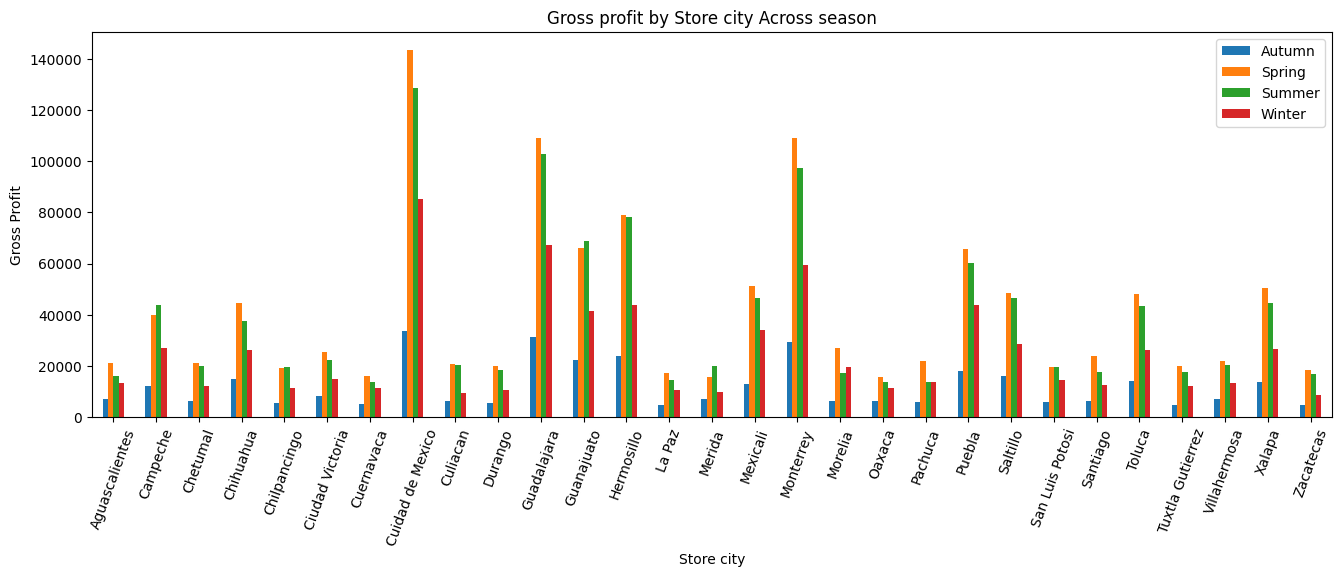

In [71]:
season_dept = df.groupby(['Season', 'Store_City'])['Gross Profit'].sum().reset_index()

pivot_sd = season_dept.pivot(index='Store_City', columns='Season', values='Gross Profit')

plt.figure(figsize=(14,5))
pivot_sd.plot(kind='bar', figsize=(16,5))
plt.title('Gross profit by Store city Across season')
plt.ylabel('Gross Profit')
plt.xlabel('Store city')
plt.xticks(rotation=70)
plt.legend()
plt.show()

- ##### **Ciudad de Mexico (Mexico City):** By far the highest-earning city, peaking at over 140,000 in gross profit during the Spring.

- ##### **Guadalajara & Monterrey:** These cities follow as the next most profitable markets, both showing a similar pattern of high performance across all seasons.

- ##### **Hermosillo & Puebla & Guadalajara:** These represent the "middle tier," maintaining solid profit margins compared to smaller regional stores.

- ##### **Zacatecas & Cuernavaca:** Among the lowest performers, with profits rarely exceeding 9,000–20,000.

-----------------------
### **3- Gross profit Across Month**
-----------------------

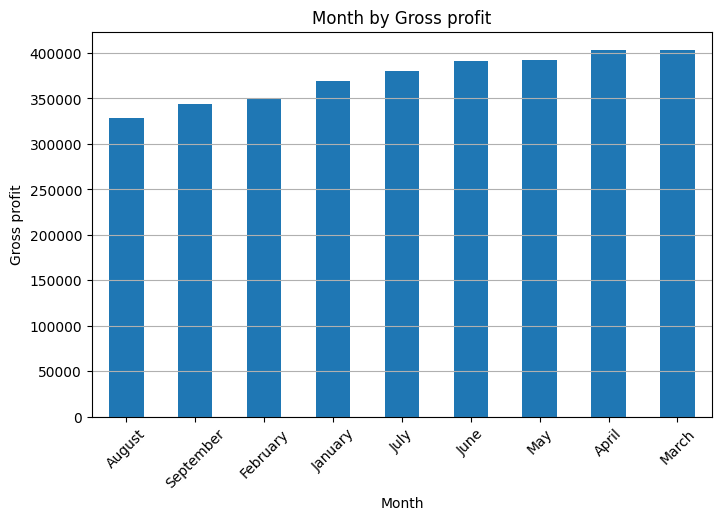

In [72]:
Month_profit = df.groupby('Month')['Gross Profit'].sum().sort_values()

plt.figure(figsize=(8,5))
Month_profit.plot(kind='bar')
plt.title('Month by Gross profit')
plt.xlabel('Month')
plt.ylabel('Gross profit')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

- ##### **Lowest Performance:** August shows the lowest gross profit, sitting just under $330,000.

- ##### **Highest Performance:** March and April are the peak months, both over than $400,000.

-----------------------
### **4- Gross profit Across Day**
-----------------------

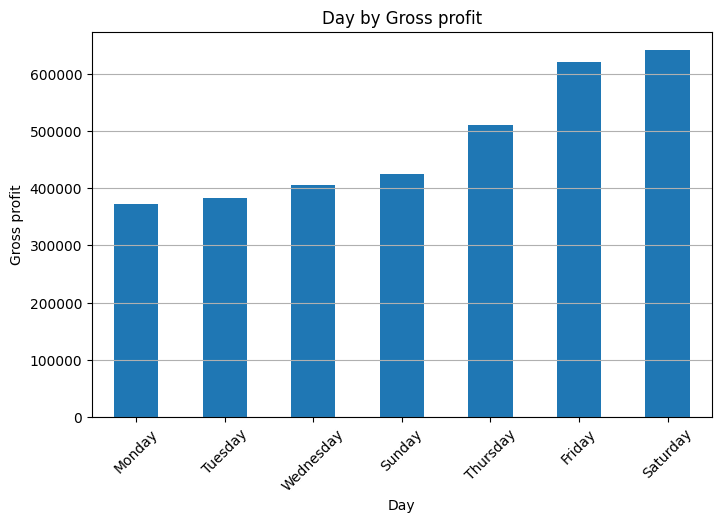

In [73]:
Day_profit = df.groupby('Day')['Gross Profit'].sum().sort_values()

plt.figure(figsize=(8,5))
Day_profit.plot(kind='bar')
plt.title('Day by Gross profit')
plt.xlabel('Day')
plt.ylabel('Gross profit')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

- ##### **Peak Performance:** Saturday is the strongest day for gross profit, reaching approximately $660,000.

- ##### **Lowest Performance:** Monday shows the lowest profit at approximately $380,000.

- ##### **Weekend Contrast:** There is a significant difference between the two weekend days; Saturday (660k) performs substantially better than Sunday ($640k).

- ##### **Late-Week Surge:** There is a sharp increase in profit starting on Thursday ($510k) and continuing through the end of the week.

----------------------------
----------------------------
## ***Analysis Stores by Gross profit across year and season and month and day***
------------------------------
### **1- Stores by Year across Gross profit**
-----------------------

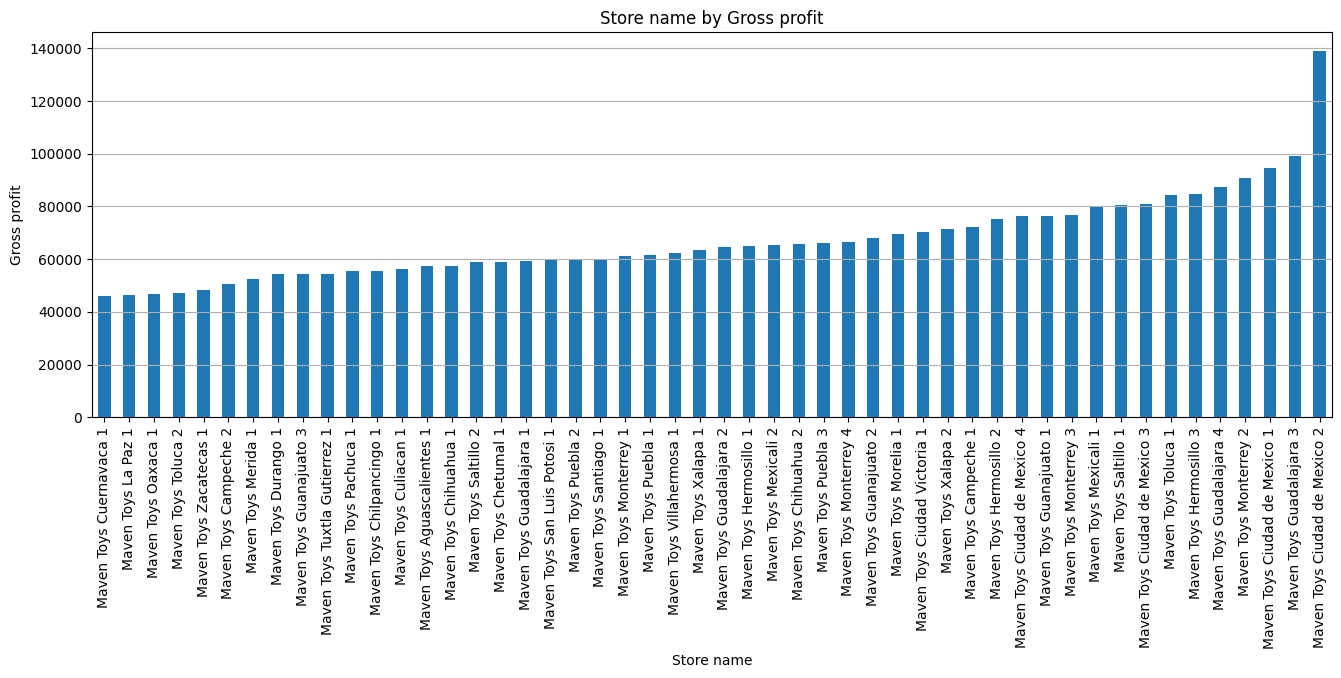

In [74]:
storeName_profit = df.groupby('Store_Name')['Gross Profit'].sum().sort_values()

plt.figure(figsize=(16,5))
storeName_profit.plot(kind='bar')
plt.title('Store name by Gross profit')
plt.xlabel('Store name')
plt.ylabel('Gross profit')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()

- ##### **Highest Performer:** Maven Toys Ciudad de Mexico 2 ($140,000)

- ##### **Runner Up :** Maven Toys Guadalajara 3 ($100,000)

- ##### **Lowest Performer :** Maven Toys Cuernavaca 1 ($48,000)

<Figure size 1400x500 with 0 Axes>

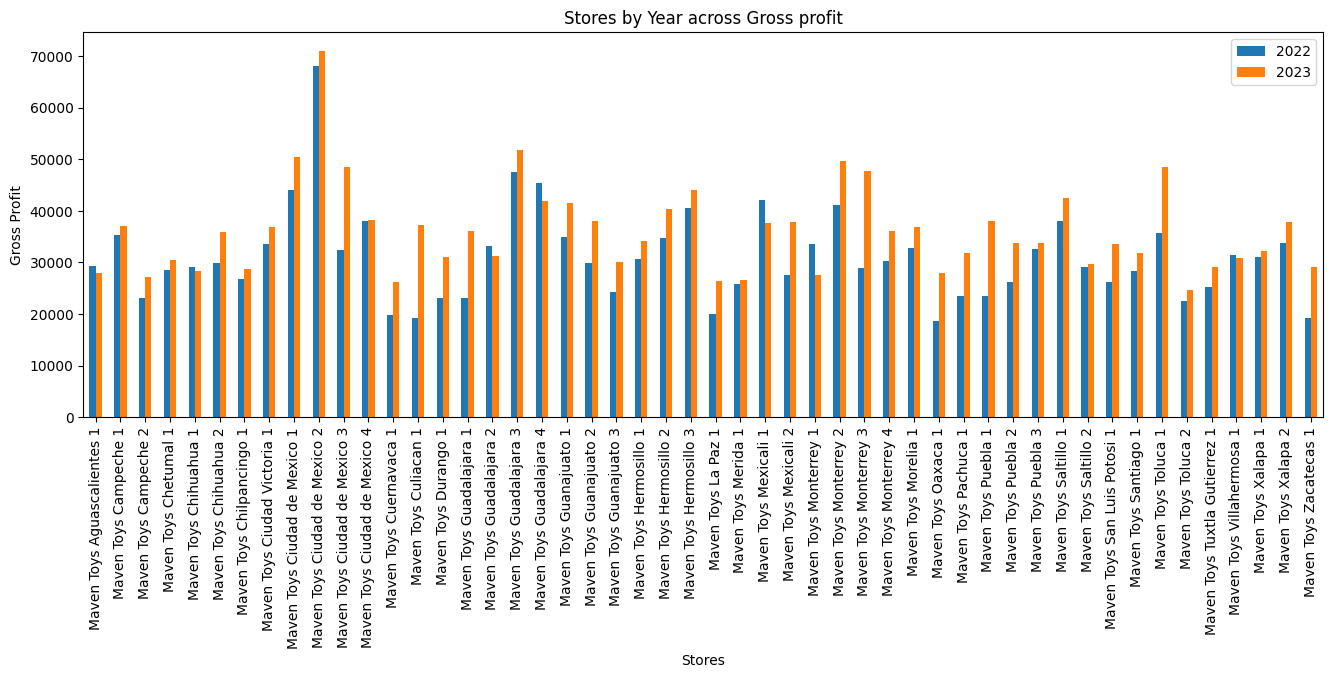

In [75]:
year_dept = df.groupby(['Year', 'Store_Name'])['Gross Profit'].sum().reset_index()

pivot_sd = year_dept.pivot(index='Store_Name', columns='Year', values='Gross Profit')

plt.figure(figsize=(14,5))
pivot_sd.plot(kind='bar', figsize=(16,5))
plt.title('Stores by Year across Gross profit')
plt.ylabel('Gross Profit')
plt.xlabel('Stores')
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [76]:
df.loc[(df['Store_Name']=='Maven Toys Ciudad de Mexico 1') | (df['Store_Name']=='Maven Toys Ciudad de Mexico 2') | (df['Store_Name']=='Maven Toys Ciudad de Mexico 3'), ['Store_Name','Year','Store_Location','Gross Profit']].groupby(['Store_Name','Year','Store_Location'])['Gross Profit'].sum()

Store_Name                     Year  Store_Location
Maven Toys Ciudad de Mexico 1  2022  Downtown          43970.0
                               2023  Downtown          50441.0
Maven Toys Ciudad de Mexico 2  2022  Airport           68033.0
                               2023  Airport           71089.0
Maven Toys Ciudad de Mexico 3  2022  Residential       32424.0
                               2023  Residential       48570.0
Name: Gross Profit, dtype: float64

In [77]:
df.loc[(df['Store_Name']=='Maven Toys Toluca 1') | (df['Store_Name']=='Maven Toys Toluca 2'), ['Store_Name','Year','Store_Location','Gross Profit']].groupby(['Store_Name','Year','Store_Location'])['Gross Profit'].sum()

Store_Name           Year  Store_Location
Maven Toys Toluca 1  2022  Downtown          35785.0
                     2023  Downtown          48553.0
Maven Toys Toluca 2  2022  Commercial        22564.0
                     2023  Commercial        24743.0
Name: Gross Profit, dtype: float64

- #### **Maven Toys Ciudad de Mexico 2: This is the highest-grossing store in the entire dataset, exceeding $70,000 in gross profit for 2023.**

- #### **Maven Toys Ciudad de Mexico 1: Also a powerhouse, maintaining high levels of profit in both years.**

- #### **Maven Toys Guadalajara 3: Stands out as the strongest performer outside of the capital city.**

-----------------------
### **2- Store city by Season Across Gross profit**
-----------------------

<Figure size 1400x500 with 0 Axes>

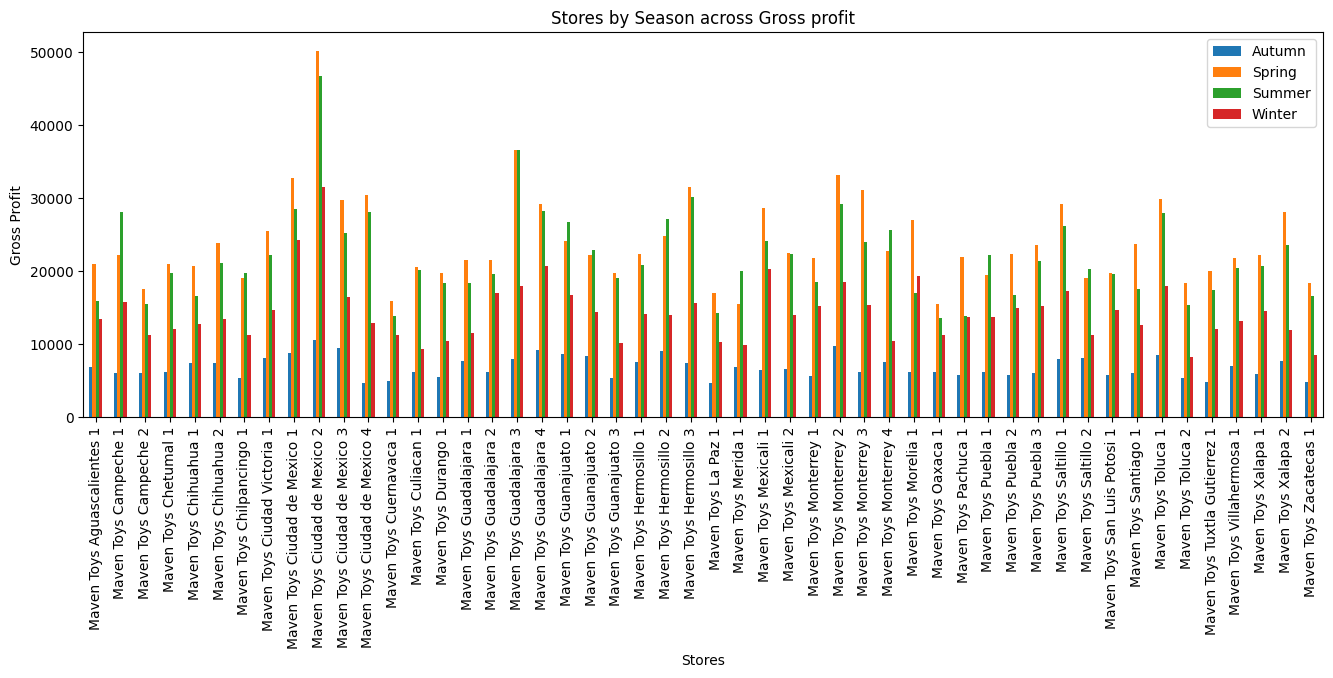

In [78]:
season_dept = df.groupby(['Season', 'Store_Name'])['Gross Profit'].sum().reset_index()

pivot_sd = season_dept.pivot(index='Store_Name', columns='Season', values='Gross Profit')

plt.figure(figsize=(14,5))
pivot_sd.plot(kind='bar', figsize=(16,5))
plt.title('Stores by Season across Gross profit')
plt.ylabel('Gross Profit')
plt.xlabel('Stores')
plt.xticks(rotation=90)
plt.legend()
plt.show()

- #### **Maven Toys Ciudad de Mexico 2:** Recorded the highest single-season profit of any store, reaching approximately $50,000 during the Spring.

- #### **Maven Toys Guadalajara 3: Showed strong seasonal performance, with Spring and Summer profits both exceeding $35,000.

- #### **Maven Toys Monterrey 2: Emerged as a top regional performer, with Spring profits surpassing $30,000.

### **Notable Observations**
- #### **Profit Volatility:** There is a massive gap between peak and low seasons. For many stores, Spring profit is more than triple the profit seen in Autumn.

- #### **Consistency:** Unlike the yearly chart where some stores fluctuated, the seasonal trend is identical across the entire fleet of stores, suggesting that consumer buying habits for toys are strictly seasonal regardless of location.

- #### **Winter Performance:** Despite the holiday season typically falling in Winter, it remains significantly less profitable than the Spring and Summer months for this business.


----------------------------
----------------------------
## ***Analysis Product category and Store location across Gross profit***
---------------------------
### **1- Gross profit by Product category and Year**
-----------------------	

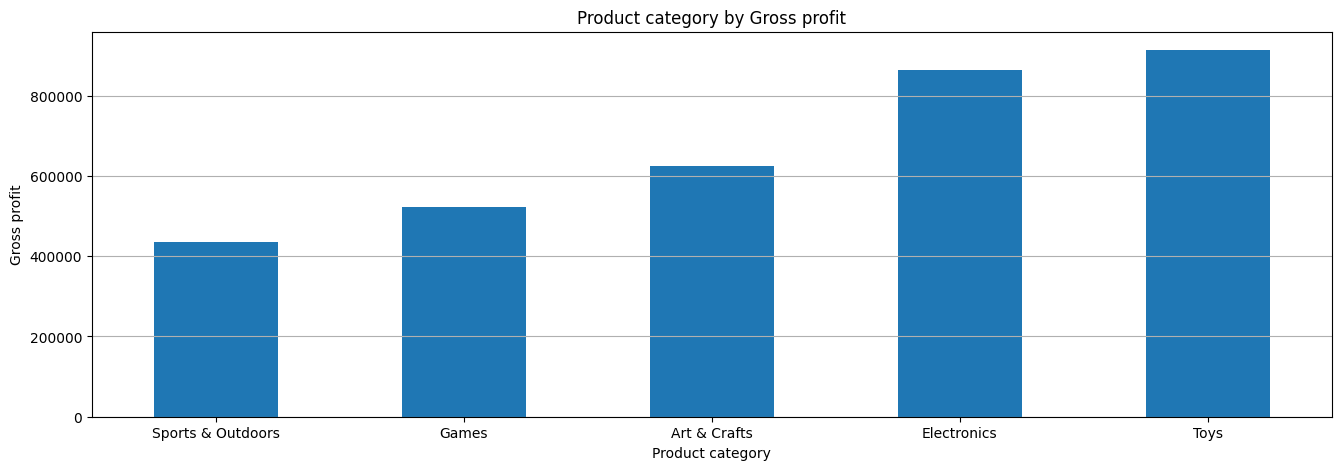

In [79]:
Product_Category_profit = df.groupby('Product_Category')['Gross Profit'].sum().sort_values()

plt.figure(figsize=(16,5))
Product_Category_profit.plot(kind='bar')
plt.title('Product category by Gross profit')
plt.xlabel('Product category')
plt.ylabel('Gross profit')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- #### **Top Performer:** The Toys department is the highest-earning category, exceeding 900,000 in gross profit.

- #### **Lowest Performer:** Sports & Outdoors has the lowest gross profit among the five categories shown.

<Figure size 1400x500 with 0 Axes>

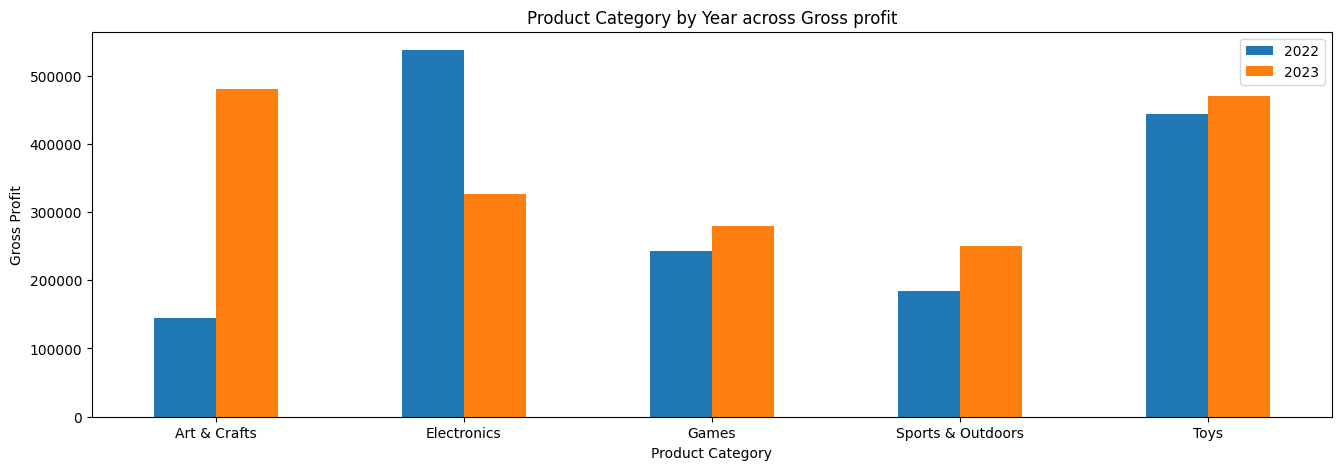

In [80]:
year_dept = df.groupby(['Year', 'Product_Category'])['Gross Profit'].sum().reset_index()

pivot_sd = year_dept.pivot(index='Product_Category', columns='Year', values='Gross Profit')

plt.figure(figsize=(14,5))
pivot_sd.plot(kind='bar', figsize=(16,5))
plt.title('Product Category by Year across Gross profit')
plt.ylabel('Gross Profit')
plt.xlabel('Product Category')
plt.xticks(rotation=0)
plt.legend()
plt.show()

- #### **Significant Growth:** Art & Crafts experienced the most substantial increase, jumping from the lowest-performing category in 2022 to the highest-performing category in 2023.

- #### **Notable Decline:** Electronics was the only category to see a decrease in gross profit, falling from its position as the clear market leader in 2022.

- #### **Consistent Growth:** Games, Sports & Outdoors, and Toys all maintained positive growth trajectories year-over-year.

---------------------------
### **2- Gross profit by Product category and Season**
-----------------------	

<Figure size 1400x500 with 0 Axes>

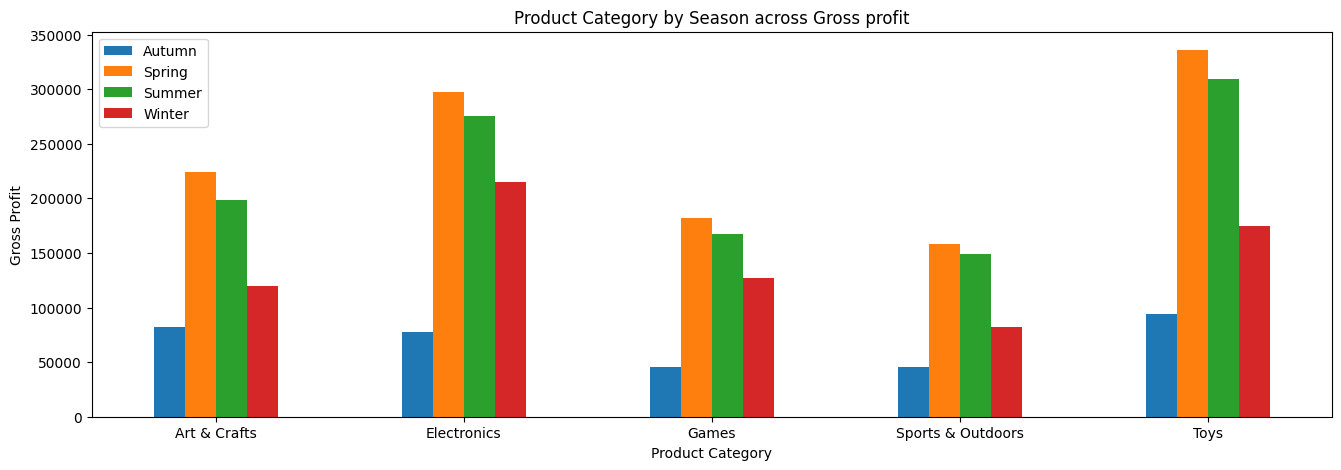

In [81]:
season_dept = df.groupby(['Season', 'Product_Category'])['Gross Profit'].sum().reset_index()

pivot_sd = season_dept.pivot(index='Product_Category', columns='Season', values='Gross Profit')

plt.figure(figsize=(14,5))
pivot_sd.plot(kind='bar', figsize=(16,5))
plt.title('Product Category by Season across Gross profit')
plt.ylabel('Gross Profit')
plt.xlabel('Product Category')
plt.xticks(rotation=0)
plt.legend()
plt.show()

- #### **The "Autumn Slump":** There is a dramatic drop in profit between Summer and Autumn. In the Electronics category, for example, profit drops from roughly 275,000 in Summer to under 80,000 in Autumn.

- #### **Electronics Resilience:** While most categories see a massive drop in Winter, Electronics maintains a relatively high gross profit ($215,000), likely due to holiday gift-giving.

- #### **Inventory Focus:** Given that Toys and Electronics generate the most profit, focusing inventory and marketing efforts on these during their peak (Spring/Summer) would yield the highest returns.

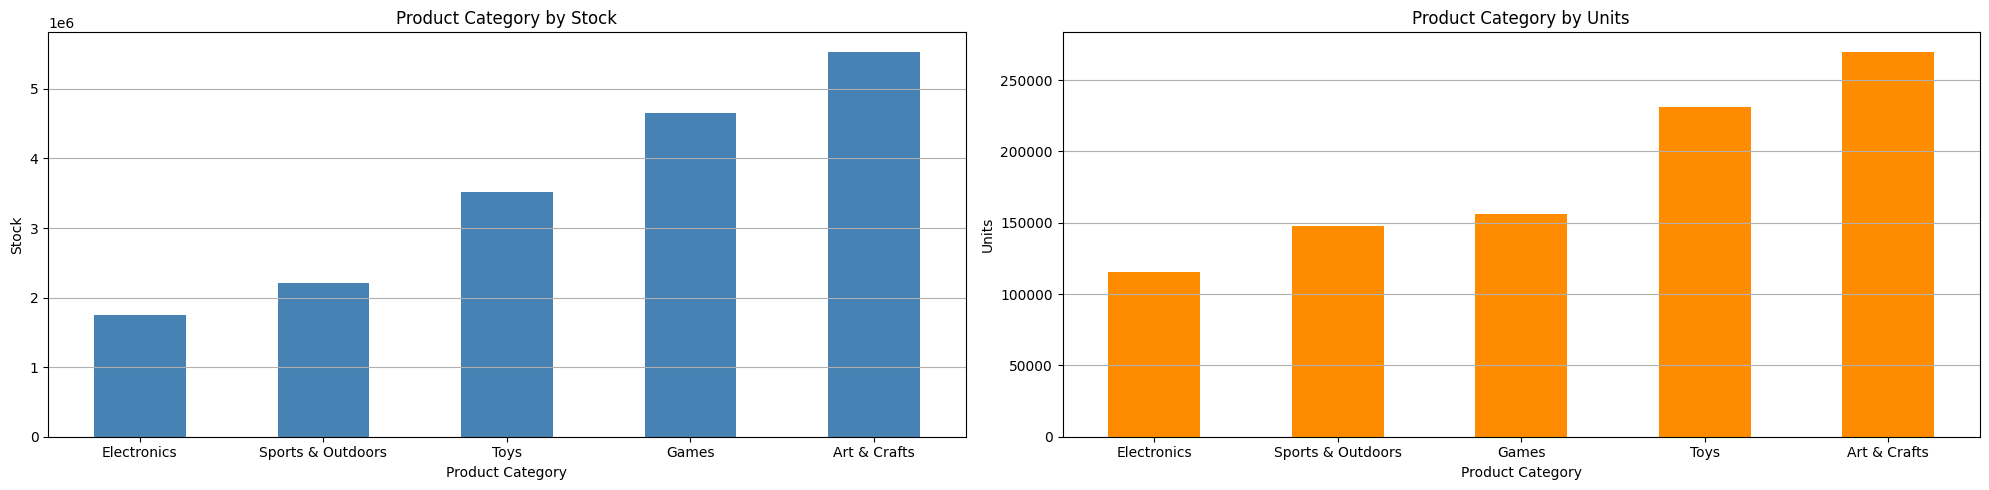

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

Product_Category_Stock = df.groupby('Product_Category')['Stock_On_Hand'].sum().sort_values()
Product_Category_Stock.plot(
    kind='bar',
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title('Product Category by Stock')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Stock')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y')

Product_Category_Units = df.groupby('Product_Category')['Units'].sum().sort_values()
Product_Category_Units.plot(
    kind='bar',
    ax=axes[1],
    color='darkorange'
)

axes[1].set_title('Product Category by Units')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Units')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

- #### **Efficiency Leader (Toys):** While Toys ranks 3rd in total stock, it is 2nd in total units sold. When combined with the fact that it is your most profitable category, this indicates a very healthy turnover rate and high demand.

- #### **High-Volume, Lower Margin (Art & Crafts):** This category moves the most units (270k) and requires the most warehouse space (5.5M stock). However, its gross profit ($225k peak) is significantly lower than Toys, suggesting these are lower-margin items sold in bulk.

- #### **Inventory Concern (Games):** This category has the 2nd highest stock level (4.6M) but only the 3rd highest unit sales (155k). It also shows lower profitability compared to Toys and Electronics. This may indicate overstocking or slower-moving inventory.

- #### **High-Value Specialty (Electronics):** This category has the lowest stock and unit sales, yet it produces the 2nd highest gross profit. This confirms that Electronics are high-ticket items where you don't need high volume to generate significant profit.

### **Strategic Recommendations**
- #### **Optimize Games Inventory:** Consider a promotional "Games" event during the peak Spring season to clear out the high stock levels and improve the stock-to-sales ratio.

- #### **Prioritize Toys:** Since Toys has high unit movement and the highest profit, ensure the supply chain for this category is prioritized to prevent stockouts during peak seasons.

----------------------------------
---------------------------------
## ***Advanced Analysis***
---------------------------------
#### **Distribution of Variables**
--------------------------

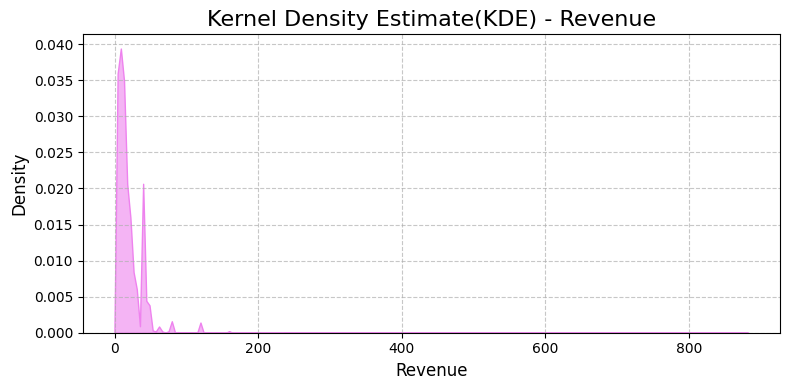

In [83]:
kde(df,'Revenue')

- #### Large block on the left : Showing the impact on the majority of the area of transactions or products that generate profits (e.g., between 0 and 50$).
- #### A large peak followed by a smaller peak at approximately 50. This indicates two product categories: a very cheap category and a mid-priced category.
- #### The Long Tail : The 2% or 5% of products that extend to the right (up to 200, 400, or even 800) are what we call High-Ticket Items.
- #### Quantity : Profit low from a large number of sales (the large green mass).
- #### Quality/Luxury : Relying on "outliers" on the far right to increase overall profits.

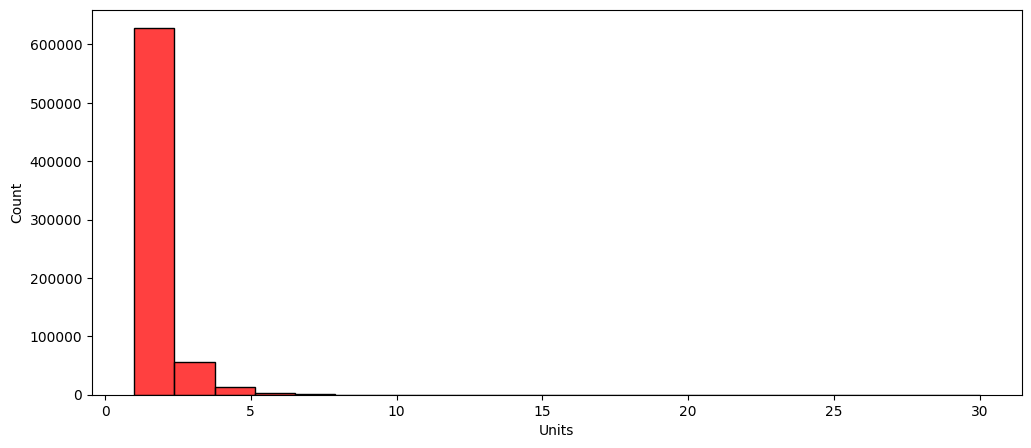

In [84]:
plt.figure(figsize=(12,5))
sns.histplot(df['Units'],kde = False, color='red')
plt.show()

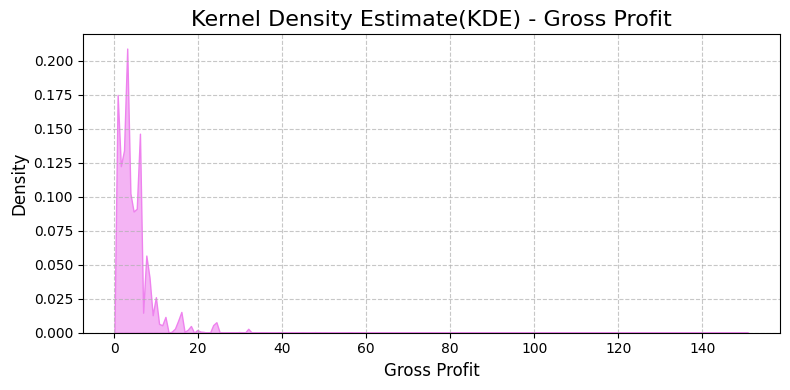

In [85]:
kde(df,'Gross Profit')

#### 1. Purchasing Behavior and Quantities (Units Histogram)
- ##### General Rule: Most customers follow a single-item pattern, resulting in a highly left-leaning distribution (Right-Skewed).

- ##### Outliers: Purchases of 30 items at once during normal times (without discounts) indicate a specific user category (donors or retailers). These represent "rare, high-impact events."

#### 2. Business Perspective
- ##### Targeting: A distinction must be made between "gaming buyers" (who ensure continuity) and "electronics buyers" (who ensure high profitability).

- ##### Growth Opportunity: The advice to slightly reduce the price of electronics aims to transform them from a "high-end" product at the bottom of the market to a "more mainstream" product, thereby increasing overall profits.

------------------------
#### **Impact of the weekend on revenue**
--------------------------

In [86]:
p_weekend = len(df[df['Weekend']=='weekend'])/len(df)
p_weekday = len(df[df['Weekend']=='no'])/len(df)
print(p_weekend)
print(p_weekday)

0.3175105063609163
0.6824894936390836


In [87]:
df.groupby('Weekend')['Revenue'].mean()

Weekend
no         17.420349
weekend    17.528430
Name: Revenue, dtype: float64

In [89]:
weekend = df[df["Weekend"]=='weekend']["Revenue"]
weekday = df[df["Weekend"]=='no']["Revenue"]

stat, p_value = stats.mannwhitneyu(weekend, weekday)

print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p-value: 0.516850
There is not a significant difference ---> H0 is not rejacted


In [90]:
dfr = 17.528 - 17.42
# campar with mean = 17.528
perc_dfr = dfr/17.528
perc_dfr*100

0.6161570059333465

- #### Although there is a statistical difference between the weekend and regular days, the magnitude of this difference is very small (0.6), indicating that the impact of the Weekend on Revenue is limited and does not justify changing the trading strategy based solely on it.


------------------------
#### **Impact of the weekend on gross profit**
--------------------------

In [91]:
df.groupby('Weekend')['Gross Profit'].mean()

Weekend
no         4.794086
weekend    4.797006
Name: Gross Profit, dtype: float64

In [92]:
weekend = df[df["Weekend"]=='weekend']["Gross Profit"]
weekday = df[df["Weekend"]=='no']["Gross Profit"]

stat, p_value = stats.mannwhitneyu(weekend, weekday)

print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p-value: 0.093630
There is not a significant difference ---> H0 is not rejacted


In [93]:
dfr = 4.797006 - 4.794086
# campar with mean = 4.797006
perc_dfr = dfr/4.797006
perc_dfr*100

0.06087130180782742

- #### There is no significant difference between Weekend and Weekday in Gross Profit
- #### Weekends may slightly affect sales, but they don't impact profitability at all
- #### There is no statistical evidence that weekends affect profitability. Furthermore, the difference between averages is very small, indicating that financial performance is stable across the days, and therefore there is no justification for adjusting the strategy based on this factor

------------------------
#### **Impact of the product category on gross profit**
--------------------------

In [94]:
df['Product_Category'].unique()

array(['Games', 'Toys', 'Sports & Outdoors', 'Art & Crafts',
       'Electronics'], dtype=object)

In [95]:
Games = df[df['Product_Category']=='Games']['Gross Profit']
Toys = df[df['Product_Category']=='Toys']['Gross Profit']
Sports_Outdoors = df[df['Product_Category']=='Sports & Outdoors']['Gross Profit']
Art_Crafts = df[df['Product_Category']=='Art & Crafts']['Gross Profit']
Electronics = df[df['Product_Category']=='Electronics']['Gross Profit']

In [96]:
df.groupby('Product_Category')['Gross Profit'].mean()

Product_Category
Art & Crafts          3.376649
Electronics          10.190290
Games                 4.150338
Sports & Outdoors     3.801794
Toys                  4.792551
Name: Gross Profit, dtype: float64

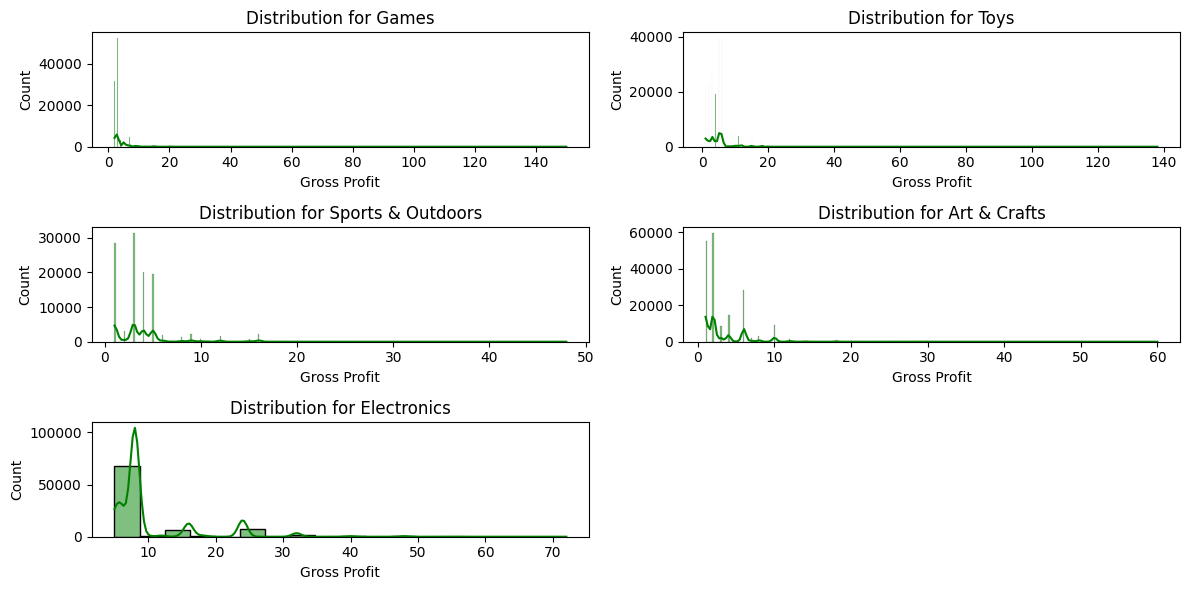

In [99]:
group_distribution(df,'Product_Category','Gross Profit')

In [100]:
stat, p_value_k = stats.kruskal(Games, Toys, Sports_Outdoors, Art_Crafts, Electronics)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 173434.136076896
P-value: 0.0
There is a significant difference


- #### The Toys category contributes to sales volume and continuity, while the Electronics category contributes more to profitability, indicating two different strategies: one to increase volume and another to increase margin.

In [101]:
df.groupby("Product_Category")[["Revenue","Gross Profit"]].sum()

,Revenue,Gross Profit
Product_Category,,
Art & Crafts,2309869.65,625065.0
Electronics,1923789.79,864320.0
Games,1776250.27,521876.0
Sports & Outdoors,1892947.58,434545.0
Toys,4324625.05,913235.0


------------------------
#### **Impact of the Store city on gross profit**
--------------------------

In [102]:
df.groupby('Store_City')['Gross Profit'].sum().sort_values(ascending=False)

Store_City
Cuidad de Mexico    390737.0
Guadalajara         310463.0
Monterrey           295163.0
Hermosillo          224626.0
Guanajuato          198795.0
Puebla              187786.0
Mexicali            145001.0
Saltillo            139431.0
Xalapa              134858.0
Toluca              131645.0
Chihuahua           123418.0
Campeche            122742.0
Ciudad Victoria      70438.0
Morelia              69706.0
Villahermosa         62457.0
Santiago             60025.0
San Luis Potosi      59721.0
Chetumal             59053.0
Aguascalientes       57251.0
Culiacan             56396.0
Chilpancingo         55402.0
Pachuca              55365.0
Tuxtla Gutierrez     54375.0
Durango              54280.0
Merida               52360.0
Zacatecas            48424.0
Oaxaca               46635.0
La Paz               46450.0
Cuernavaca           46038.0
Name: Gross Profit, dtype: float64

In [103]:
cities_mean=(df.groupby('Store_City')['Gross Profit'].mean().sort_values(ascending=False)).to_dict()
cities_mean

{'Morelia': 5.685180654106516,
 'Hermosillo': 5.29042134765303,
 'Ciudad Victoria': 5.133216732254773,
 'Mexicali': 5.118103843845963,
 'Cuidad de Mexico': 5.069173985807138,
 'Guadalajara': 4.990082936865115,
 'Monterrey': 4.959472401915484,
 'Saltillo': 4.9499786992331725,
 'Campeche': 4.791988756148981,
 'Puebla': 4.763119847812302,
 'Guanajuato': 4.760530664048469,
 'Chihuahua': 4.749769088669951,
 'Xalapa': 4.738177218747804,
 'Aguascalientes': 4.672025461073935,
 'Chetumal': 4.661220301523404,
 'Villahermosa': 4.526525583417887,
 'Chilpancingo': 4.522612244897959,
 'Culiacan': 4.464887974032143,
 'Santiago': 4.45884712524142,
 'Durango': 4.429574016647625,
 'San Luis Potosi': 4.4247610580128915,
 'Tuxtla Gutierrez': 4.417140536149472,
 'Zacatecas': 4.367243867243867,
 'Toluca': 4.347445592946071,
 'Pachuca': 4.294856876890854,
 'Merida': 4.231111111111111,
 'La Paz': 4.212387775460234,
 'Oaxaca': 4.126625962304221,
 'Cuernavaca': 4.02324565236389}

In [ ]:
cities_mean.values()

In [104]:
stat, p_value_k = stats.kruskal(5.685180654106516, 5.29042134765303, 5.133216732254773, 5.118103843845963, 5.069173985807138,
                                4.990082936865115, 4.959472401915484, 4.9499786992331725, 4.791988756148981, 4.763119847812302, 
                                4.760530664048469, 4.749769088669951, 4.738177218747804, 4.672025461073935, 4.661220301523404, 
                                4.526525583417887, 4.522612244897959, 4.464887974032143, 4.45884712524142, 4.429574016647625, 
                                4.4247610580128915, 4.417140536149472, 4.367243867243867, 4.347445592946071, 4.294856876890854, 
                                4.231111111111111, 4.212387775460234, 4.126625962304221, 4.02324565236389)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 28.0
P-value: 0.46444756489685685
There is not a significant difference


- #### The difference in averages may be due to outliers, while the overall distribution of profits across cities is similar, which explains the lack of a statistically significant difference
- #### There is no statistical evidence of performance differences between cities, so before making marketing decisions, we need a deeper analysis of factors such as demand, inventory, and location

------------------------
#### **Impact of Store location on gross profit**
--------------------------

<Figure size 1400x500 with 0 Axes>

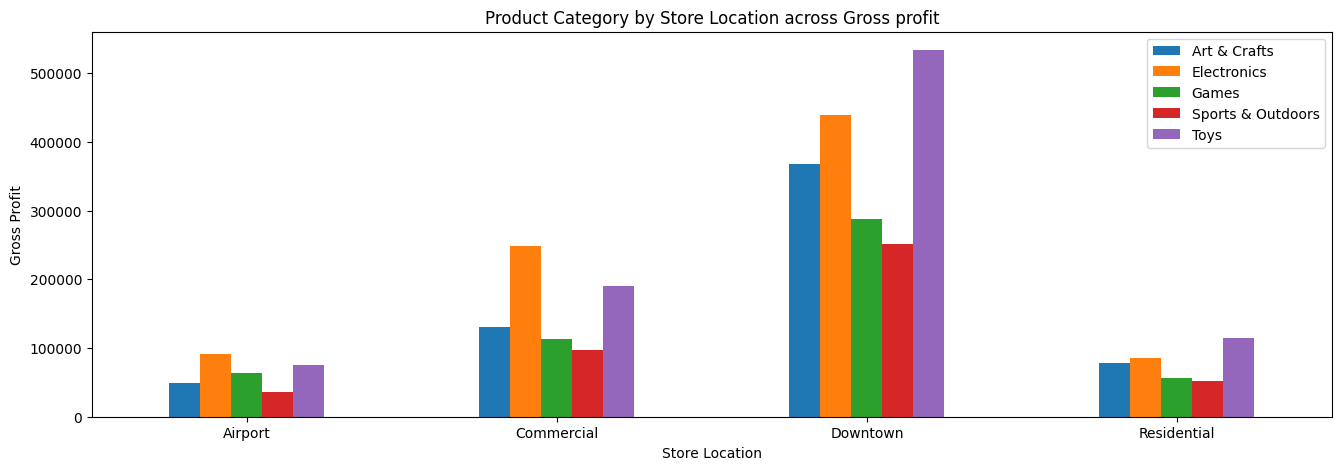

In [105]:
season_dept = df.groupby(['Product_Category', 'Store_Location'])['Gross Profit'].sum().reset_index()

pivot_sd = season_dept.pivot(index='Store_Location', columns='Product_Category', values='Gross Profit')

plt.figure(figsize=(14,5))
pivot_sd.plot(kind='bar', figsize=(16,5))
plt.title('Product Category by Store Location across Gross profit')
plt.ylabel('Gross Profit')
plt.xlabel('Store Location')
plt.xticks(rotation=0)
plt.legend()
plt.show()

- #### Stores in downtown tend to perform better, and this may be related to factors such as customer density and traffic, requiring further analysis to determine the true cause

In [106]:
location_mean = (df.groupby('Store_Location')['Gross Profit'].mean()).to_dict()
location_mean

{'Airport': 5.467527284715354,
 'Commercial': 4.988115069195285,
 'Downtown': 4.629300317410248,
 'Residential': 4.774592439930397}

In [107]:
location_mean.values()

dict_values([5.467527284715354, 4.988115069195285, 4.629300317410248, 4.774592439930397])

In [108]:
stat, p_value_k = stats.kruskal(5.467527284715354, 4.988115069195285, 4.629300317410248, 4.774592439930397)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 3.0
P-value: 0.3916251762710877
There is not a significant difference


------------------------
#### **Impact of Store age seg on gross profit**
--------------------------

In [109]:
store_age_mean = (df.groupby('Store age seg')['Gross Profit'].mean()).to_dict()
store_age_mean

{'Established': 5.005136883246538,
 'Experienced': 4.6302007615091725,
 'Legacy': 4.514449567075228,
 'Mature': 4.714611088316321,
 'Senior': 4.692793653125689}

In [110]:
store_age_mean.values()

dict_values([5.005136883246538, 4.6302007615091725, 4.514449567075228, 4.714611088316321, 4.692793653125689])

In [111]:
stat, p_value_k = stats.kruskal(5.005136883246538, 4.6302007615091725, 4.514449567075228, 4.714611088316321, 4.692793653125689)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 4.0
P-value: 0.40600584970983794
There is not a significant difference


- #### Through hypothesis testing, i observe that geographical location and store type have no effect on performance.

--------------------------------------------
# <center><strong>Conclusion & Recommendation</strong></center>
--------------------------------------------
#### **The data indicates that performance differences are not dependent on a single factor, but rather result from the interaction of several factors such as location, product type, and store age. Some variables, such as city, weekend, product type, and store location, did not show a statistically significant impact. Therefore, it is advisable to rely on well-designed A/B testing and optimize scalable factors, such as store upgrades and targeting high-traffic locations, before making major strategic decisions.**
#### **We recommend applying the discount experimentally to the Electronics category only, given its high profit margin, while monitoring the impact on demand and profitability, while the rest of the categories remain stable due to their good performance in terms of sales volume.**

---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "Maven Toys Analysis.ipynb"

[NbConvertApp] Converting notebook Maven Toys Analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 30 image(s).
[NbConvertApp] Writing 2252186 bytes to Maven Toys Analysis.html
